# **Indonesian Credit Score**

---

# **Library**

In [1]:
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

!pip install category_encoders
import category_encoders as ce
from lightgbm import LGBMClassifier, early_stopping

!pip install optuna
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibility
SEED = 50
def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(SEED)
    np.random.seed(SEED)
seed_everything(SEED)

# Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 12,
})
PALETTE = ["#2ecc71", "#e74c3c"]  # green=lancar, red=default

print("Libraries loaded successfully!")

Libraries loaded successfully!



# **Load Data & Gambaran Umum Dataset**

In [2]:
df_train = pd.read_csv("IndonesianCreditScore.csv")

print(f"Ukuran data train : {df_train.shape}")
print()
print(df_train.info())
print()
df_train.head()

Ukuran data train : (20012, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20012 entries, 0 to 20011
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_transaksi               20012 non-null  int64  
 1   tanggal_pencairan          20012 non-null  object 
 2   provinsi                   20012 non-null  object 
 3   jenis_pinjaman             19543 non-null  object 
 4   status_peminjam            20012 non-null  object 
 5   jumlah_pinjaman            20012 non-null  float64
 6   total_pengembalian         17947 non-null  float64
 7   durasi_hari                19212 non-null  float64
 8   porsi_pengembalian_lender  18052 non-null  float64
 9   sektor_usaha               20012 non-null  object 
 10  pendidikan                 20012 non-null  object 
 11  jenis_jaminan              20012 non-null  object 
 12  status_gagal_bayar         20012 non-null  int64  
dtypes: float64(4)

,id_transaksi,tanggal_pencairan,provinsi,jenis_pinjaman,status_peminjam,jumlah_pinjaman,total_pengembalian,durasi_hari,porsi_pengembalian_lender,sektor_usaha,pendidikan,jenis_jaminan,status_gagal_bayar
0,1,2023-08-01,Jawa Barat,Modal_Usaha,Peminjam_Berulang,959000.0,959000.0,7.0,287000.0,Digital,D3,Sertifikat,0
1,2,2023-08-12,Jawa Tengah,Modal_Usaha,Peminjam_Berulang,55000.0,55000.0,7.0,16000.0,Kuliner,S2,SK_Pegawai,0
2,3,2023-08-05,Jawa Barat,Modal_Usaha,Peminjam_Berulang,655000.0,666000.0,7.0,199000.0,Digital,SMA,Sertifikat,0
3,4,2025-10-28,Jawa Tengah,Mikro_UKM,Peminjam_Berulang,611000.0,632000.0,7.0,126000.0,Kuliner,S1,BPKB,0
4,5,2023-09-09,Jawa Timur,Modal_Usaha,Peminjam_Berulang,573000.0,573000.0,7.0,127000.0,Perdagangan,S2,Tanpa_Jaminan,0


## Data Dictionary

| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `id_transaksi` | int | ID unik setiap transaksi pinjaman |
| `tanggal_pencairan` | date | Tanggal pinjaman dicairkan |
| `provinsi` | categorical | Provinsi domisili peminjam |
| `jenis_pinjaman` | categorical | Tujuan pinjaman (Modal Usaha, Konsumtif, dll.) |
| `status_peminjam` | categorical | Apakah peminjam baru atau berulang |
| `jumlah_pinjaman` | float | Nominal pinjaman (IDR) |
| `total_pengembalian` | float | Total yang harus dikembalikan (pokok + bunga) |
| `durasi_hari` | float | Tenor pinjaman dalam hari |
| `porsi_pengembalian_lender` | float | Porsi uang yang kembali ke lender |
| `sektor_usaha` | categorical | Sektor bisnis peminjam |
| `pendidikan` | categorical | Tingkat pendidikan terakhir peminjam |
| `jenis_jaminan` | categorical | Jenis agunan/jaminan yang diberikan |
| `status_gagal_bayar` | **TARGET** | 1 = Gagal Bayar, 0 = Lancar |

# **Exploratory Data Analysis (EDA)**

## Class Imbalance

Pada kasus ini, jumlah pinjaman yang bermasalah jauh lebih sedikit dan ini disebut **class imbalance**.

Class imbalance yang ekstrem akan membuat model "malas" memprediksi kelas minoritas (gagal bayar) karena cukup memprediksi semua sebagai "lancar" pun bisa mencapai akurasi ~95%.

> Harus menggunakan **F1-Macro** sebagai metrik utama (bukan akurasi), dan menerapkan strategi seperti `scale_pos_weight` di LightGBM untuk menyeimbangkan pembelajaran.

In [3]:
y = df_train["status_gagal_bayar"]
X = df_train.drop(columns=["status_gagal_bayar"])

In [4]:
counts = y.value_counts()
pcts   = y.value_counts(normalize=True) * 100

print("DISTRIBUSI TARGET (status_gagal_bayar)")
print(f"  Lancar  (0)     : {counts[0]:,} transaksi  ({pcts[0]:.2f}%)")
print(f"  Gagal Bayar (1) : {counts[1]:,} transaksi  ({pcts[1]:.2f}%)")
print(f"  Rasio Imbalance : {counts[0]/counts[1]:.1f}:1")

DISTRIBUSI TARGET (status_gagal_bayar)
  Lancar  (0)     : 19,006 transaksi  (94.97%)
  Gagal Bayar (1) : 1,006 transaksi  (5.03%)
  Rasio Imbalance : 18.9:1


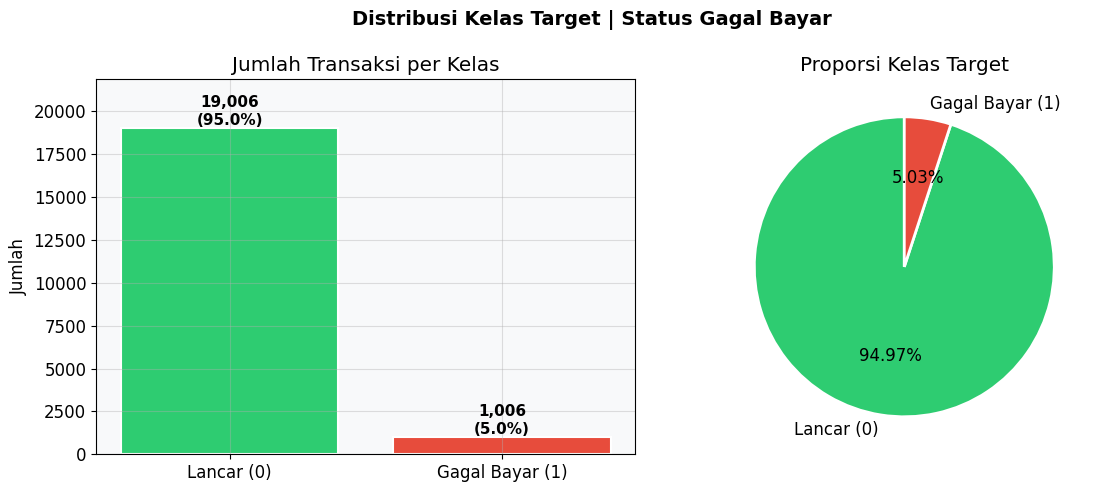

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribusi Kelas Target | Status Gagal Bayar", fontsize=14, fontweight="bold")

axes[0].bar(["Lancar (0)", "Gagal Bayar (1)"], [counts[0], counts[1]],
            color=PALETTE, edgecolor="white", linewidth=1.5)
axes[0].set_title("Jumlah Transaksi per Kelas")
axes[0].set_ylabel("Jumlah")
for i, (v, p) in enumerate(zip([counts[0], counts[1]], [pcts[0], pcts[1]])):
    axes[0].text(i, v + 200, f"{v:,}\n({p:.1f}%)", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, max(counts) * 1.15)

axes[1].pie([counts[0], counts[1]], labels=["Lancar (0)", "Gagal Bayar (1)"],
            colors=PALETTE, autopct="%1.2f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporsi Kelas Target")

plt.tight_layout()
plt.show()

**INSIGHT**:\
Dataset sangat tidak seimbang karena hanya ~5% transaksi yang gagal bayar. Jadi model harus dioptimasi untuk menangani imbalance data. Maka, metrik F1-Macro dipilih karena tidak bias terhadap kelas mayoritas.

## Analisis Fitur Kategorikal

1. Mengidentifikasi **faktor risiko** yang paling signifikan
2. Membuat keputusan apakah perlu **encoding khusus** atau **rare category bucketing**
3. Menentukan apakah fitur tersebut memiliki **discriminative power** terhadap target

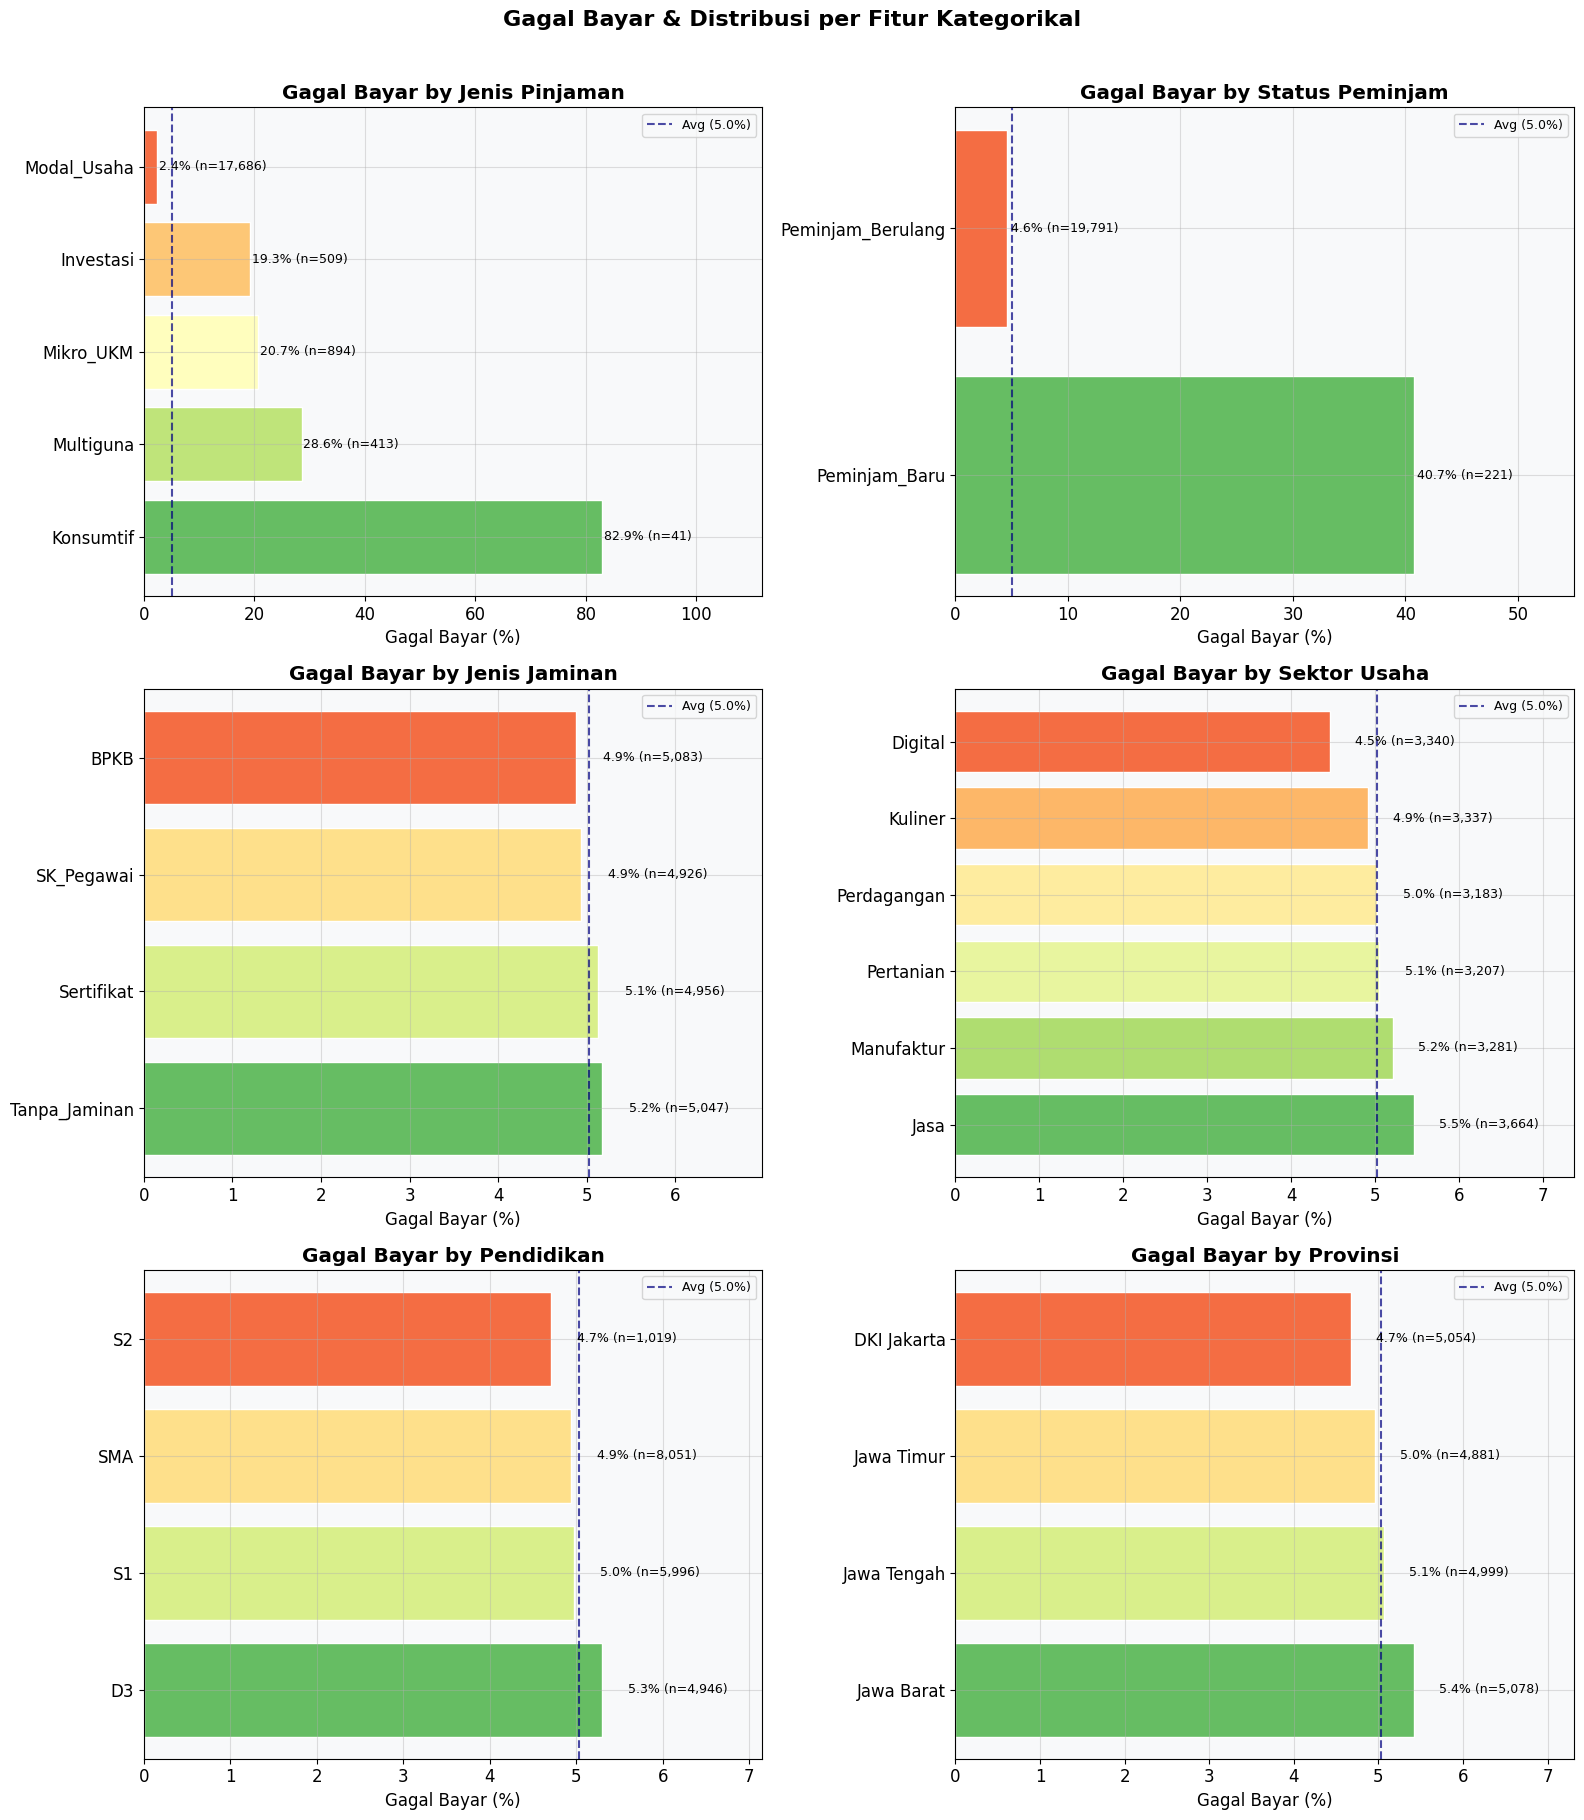

In [6]:
cat_features = {
    "jenis_pinjaman":  "Jenis Pinjaman",
    "status_peminjam": "Status Peminjam",
    "jenis_jaminan":   "Jenis Jaminan",
    "sektor_usaha":    "Sektor Usaha",
    "pendidikan":      "Pendidikan",
    "provinsi":        "Provinsi",
}

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()
fig.suptitle("Gagal Bayar & Distribusi per Fitur Kategorikal", fontsize=16, fontweight="bold", y=1.01)

for idx, (col, label) in enumerate(cat_features.items()):
    ax = axes[idx]
    stats = df_train.groupby(col).agg(
        count=("status_gagal_bayar", "count"),
        default_rate=("status_gagal_bayar", "mean")
    ).reset_index().sort_values("default_rate", ascending=False)

    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(stats)))
    bars = ax.barh(stats[col], stats["default_rate"] * 100, color=colors, edgecolor="white")
    ax.set_title(f"Gagal Bayar by {label}", fontweight="bold")
    ax.set_xlabel("Gagal Bayar (%)")
    ax.axvline(x=y.mean()*100, color="navy", linestyle="--", alpha=0.7, label=f"Avg ({y.mean()*100:.1f}%)")
    ax.legend(fontsize=9)
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{row.default_rate*100:.1f}% (n={row['count']:,})", va="center", fontsize=9)
    ax.set_xlim(0, stats["default_rate"].max() * 100 * 1.35)

plt.tight_layout()
plt.show()

**Insight Fitur Kategorikal:**

| Fitur | Temuan | Implikasi Model |
|-------|--------|-----------------|
| **Jenis Pinjaman** | `Konsumtif` gagal bayar 82.9% vs `Modal_Usaha` hanya 2.4%. perbedaan ini sangat ekstrem | Fitur paling diskriminatif; prediktor terkuat |
| **Status Peminjam** | `Peminjam_Baru` default 40.7% vs `Peminjam_Berulang` 4.6% | Peminjam baru jauh lebih berisiko karena tidak ada track record |
| **Jenis Jaminan** | Perbedaan kecil (~0.3%) antar kategori | Fitur ini kurang diskriminatif |
| **Sektor Usaha** | Variasi kecil (4.5–5.5%) | Faktor risiko sektor tidak signifikan |
| **Pendidikan** | Hampir tidak ada perbedaan | Bukan prediktor kuat dalam dataset ini |

> `jenis_pinjaman` memiliki **469 missing values** (2.3%). Baris yang missing `jenis_pinjaman` memiliki default rate **30.3%** dimana hal tersebut jauh lebih tinggi dari rata-rata 5%. Ini menunjukkan missingness bukan acak, melainkan **informatif (MAR/MNAR)**. Data akan diisi dengan label khusus `"Unknown"` dan membuat kolom is_missing.


## Analisis Fitur Numerik

Distribusi fitur numerik, terutama perbedaan antara kelas 0 (lancar) dan 1 (gagal bayar) menunjukkan seberapa besar **separability** yang bisa diekstrak oleh model.

In [7]:
df_eda = df_train.copy()
df_eda["bunga_margin"] = (
    df_eda["total_pengembalian"].fillna(df_eda["jumlah_pinjaman"]) - df_eda["jumlah_pinjaman"]
) / (df_eda["jumlah_pinjaman"] + 1)

numeric_feats = {
    "jumlah_pinjaman": "Jumlah Pinjaman (IDR)",
    "durasi_hari": "Durasi Hari",
    "bunga_margin": "Margin Bunga (derived)",
    "porsi_pengembalian_lender": "Porsi Pengembalian Lender",
}

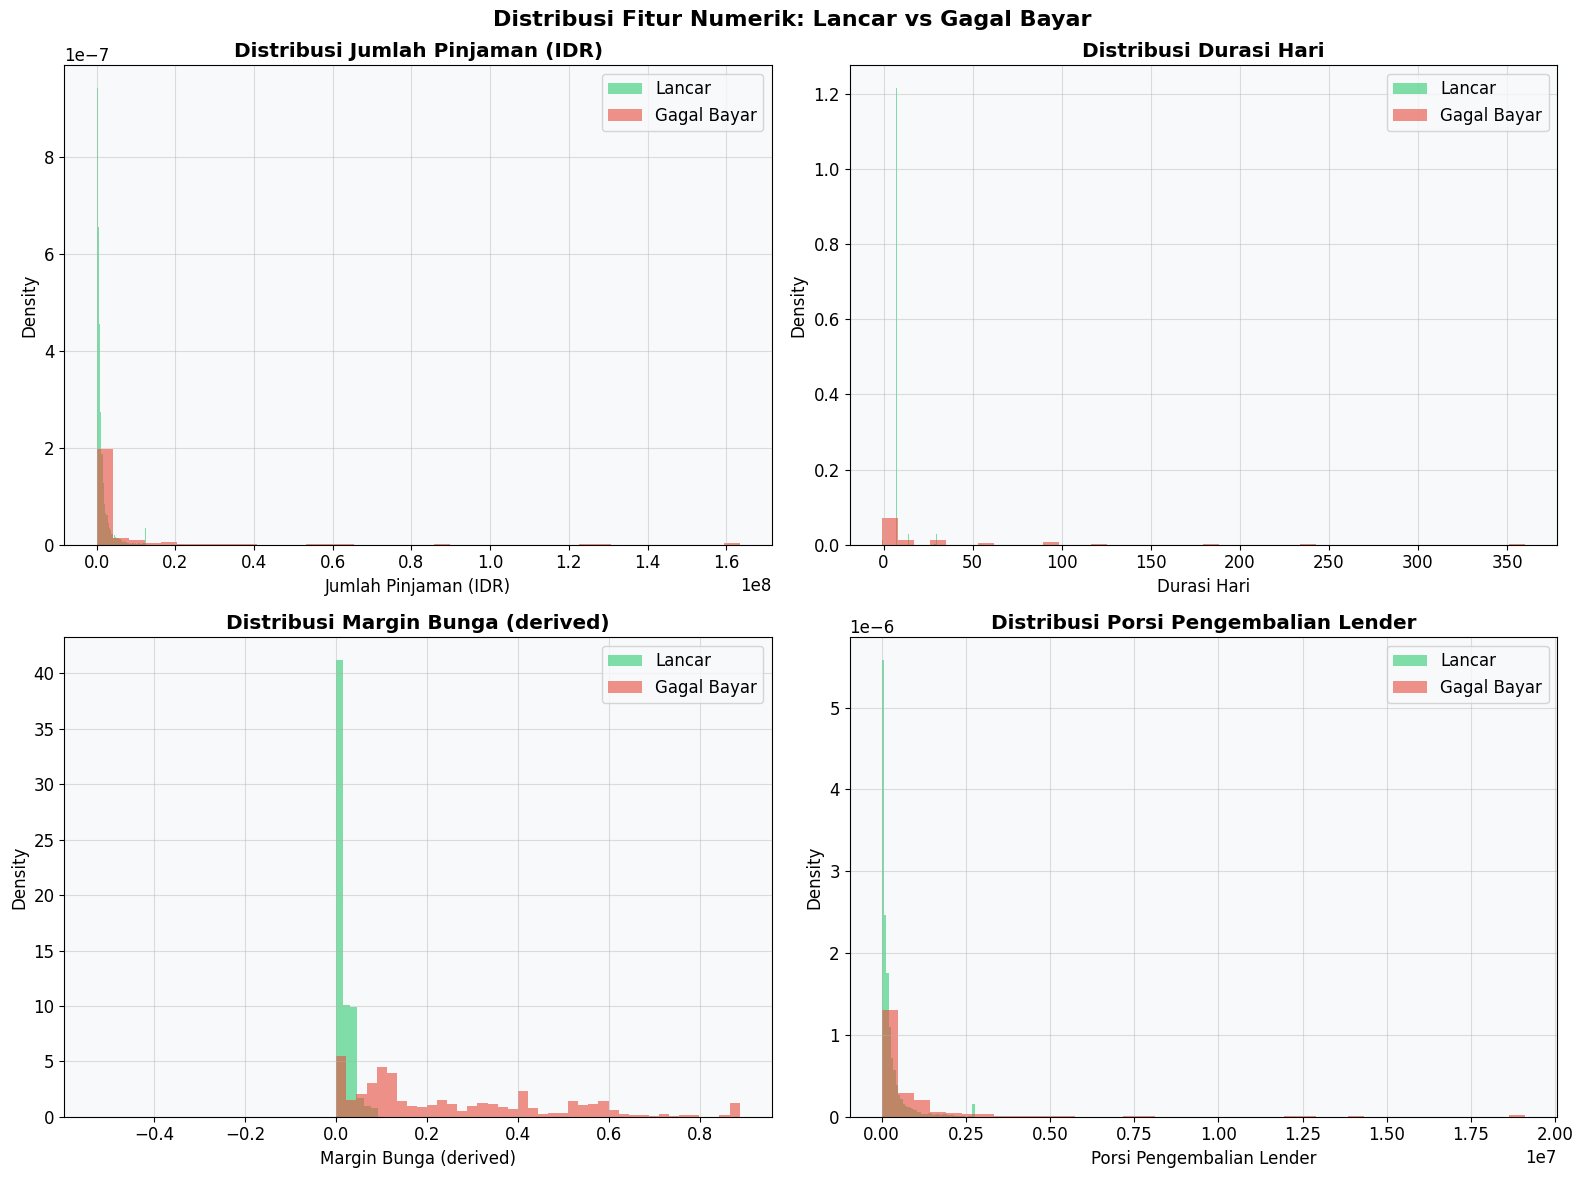

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle("Distribusi Fitur Numerik: Lancar vs Gagal Bayar", fontsize=16, fontweight="bold")

for idx, (col, label) in enumerate(numeric_feats.items()):
    ax = axes[idx]
    for label_val, color, name in [(0, PALETTE[0], "Lancar"), (1, PALETTE[1], "Gagal Bayar")]:
        data = df_eda[df_eda["status_gagal_bayar"] == label_val][col].dropna()
        cap  = data.quantile(0.99)
        data_capped = data.clip(upper=cap)
        ax.hist(data_capped, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(f"Distribusi {label}", fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
print("KORELASI FITUR NUMERIK vs STATUS GAGAL BAYAR")
num_cols_check = ["jumlah_pinjaman", "total_pengembalian", "durasi_hari",
                  "porsi_pengembalian_lender", "bunga_margin"]
for col in num_cols_check:
    corr = df_eda[[col, "status_gagal_bayar"]].corr().iloc[0, 1]
    bar  = "=" * int(abs(corr) * 40)
    print(f"  {col:<35} {corr:+.4f}  {bar}")

KORELASI FITUR NUMERIK vs STATUS GAGAL BAYAR
  jumlah_pinjaman                     +0.0933  ===
  total_pengembalian                  +0.0927  ===
  durasi_hari                         +0.2236  ========
  porsi_pengembalian_lender           +0.1165  ====
  bunga_margin                        +0.6682  ==========================


bunga_margin memiliki korelasi tertinggi (0.67) dimana ini merupakan fitur yang paling kuat

**Insight dari Fitur Numerik:**

| Fitur | Korelasi dengan Target | Interpretasi |
|-------|----------------------|--------------|
| `bunga_margin` *(derived)* | **+0.67** | Margin bunga sangat tinggi = tanda risiko tinggi; pinjaman "mahal" cenderung gagal |
| `durasi_hari` | +0.22 | Tenor lebih panjang = risiko lebih tinggi |
| `porsi_pengembalian_lender` | +0.12 | Nominal absolut kurang informatif; perlu dinormalisasi |
| `jumlah_pinjaman` | +0.09 | Korelasi lemah secara langsung |
| `total_pengembalian` | +0.09 | Korelasi lemah secara langsung |

> **Kesimpulan:** Fitur-fitur raw memiliki korelasi rendah secara individual. **Feature engineering** (membuat `bunga_margin`, `beban_cicilan`, `rasio_lender`, dll.) sangat krusial untuk meningkatkan performa model.

---
## Analisis Missing Values

Memahami pola missingness dan korelasinya dengan target untuk menentukan strategi penanganan yang tepat.

In [10]:
missing     = df_train.isnull().sum()
missing     = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_train) * 100).round(2)

In [11]:
print("MISSING VALUES OVERVIEW")
print("=" * 70)
for col, cnt in missing.items():
    pct = missing_pct[col]
    bar = "=" * int(pct * 2)
    print(f"  {col:<38} {cnt:>5} ({pct:5.1f}%)  {bar}")

MISSING VALUES OVERVIEW
  total_pengembalian                      2065 ( 10.3%)  ====================
  porsi_pengembalian_lender               1960 (  9.8%)  ===================
  durasi_hari                              800 (  4.0%)  ========
  jenis_pinjaman                           469 (  2.3%)  ====


In [12]:
print("APAKAH POLA MISSING INFORMATIF? (gagal bayar saat missing vs tidak)")
print("=" * 70)
print(f"  {'Kolom':<38} {'Missing DR':>12} {'Non-Missing DR':>15}")
print("-" * 70)
for col in missing.index:
    mask_miss  = df_train[col].isnull()
    dr_miss    = df_train[mask_miss]["status_gagal_bayar"].mean()
    dr_present = df_train[~mask_miss]["status_gagal_bayar"].mean()
    flag = " <-- INFORMATIF!" if abs(dr_miss - dr_present) > 0.05 else ""
    print(f"  {col:<38} {dr_miss:>10.1%} {dr_present:>14.1%}  {flag}")

APAKAH POLA MISSING INFORMATIF? (gagal bayar saat missing vs tidak)
  Kolom                                    Missing DR  Non-Missing DR
----------------------------------------------------------------------
  total_pengembalian                           5.4%           5.0%  
  porsi_pengembalian_lender                    5.1%           5.0%  
  durasi_hari                                  4.5%           5.0%  
  jenis_pinjaman                              30.3%           4.4%   <-- INFORMATIF!


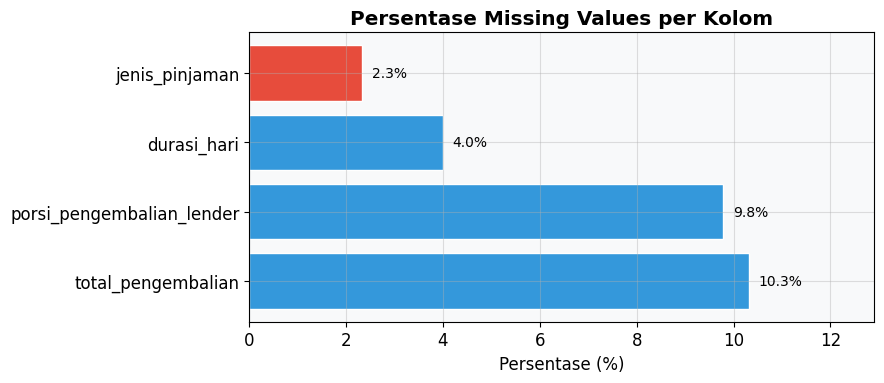

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ["#e74c3c" if c == "jenis_pinjaman" else "#3498db" for c in missing.index]
ax.barh(missing.index, missing_pct, color=colors_bar, edgecolor="white")
ax.set_title("Persentase Missing Values per Kolom", fontweight="bold")
ax.set_xlabel("Persentase (%)")
for i, (col, pct) in enumerate(missing_pct.items()):
    ax.text(pct + 0.2, i, f"{pct:.1f}%", va="center", fontsize=10)
ax.set_xlim(0, max(missing_pct) * 1.25)
plt.tight_layout()
plt.show()

**INSIGHT MISSINGNESS**\
jenis_pinjaman: 30.3% gagal bayar saat MISSING vs 4.4% saat ada.
Buat kolom is_missing + isi dengan label 'Unknown'.
Kolom lain: pola missing tidak jauh berbeda dimana imputation standar sudah cukup.

## Analisis Temporal

Waktu pencairan pinjaman dapat mengandung **seasonal patterns** atau **trend** yang mempengaruhi risiko gagal bayar.

In [14]:
df_eda["tanggal_pencairan"] = pd.to_datetime(df_eda["tanggal_pencairan"], errors="coerce")
df_eda["bulan"]       = df_eda["tanggal_pencairan"].dt.month
df_eda["hari_minggu"] = df_eda["tanggal_pencairan"].dt.day_name()
df_eda["tgl"]         = df_eda["tanggal_pencairan"].dt.day

month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"Mei",6:"Jun",
               7:"Jul",8:"Ags",9:"Sep",10:"Okt",11:"Nov",12:"Des"}

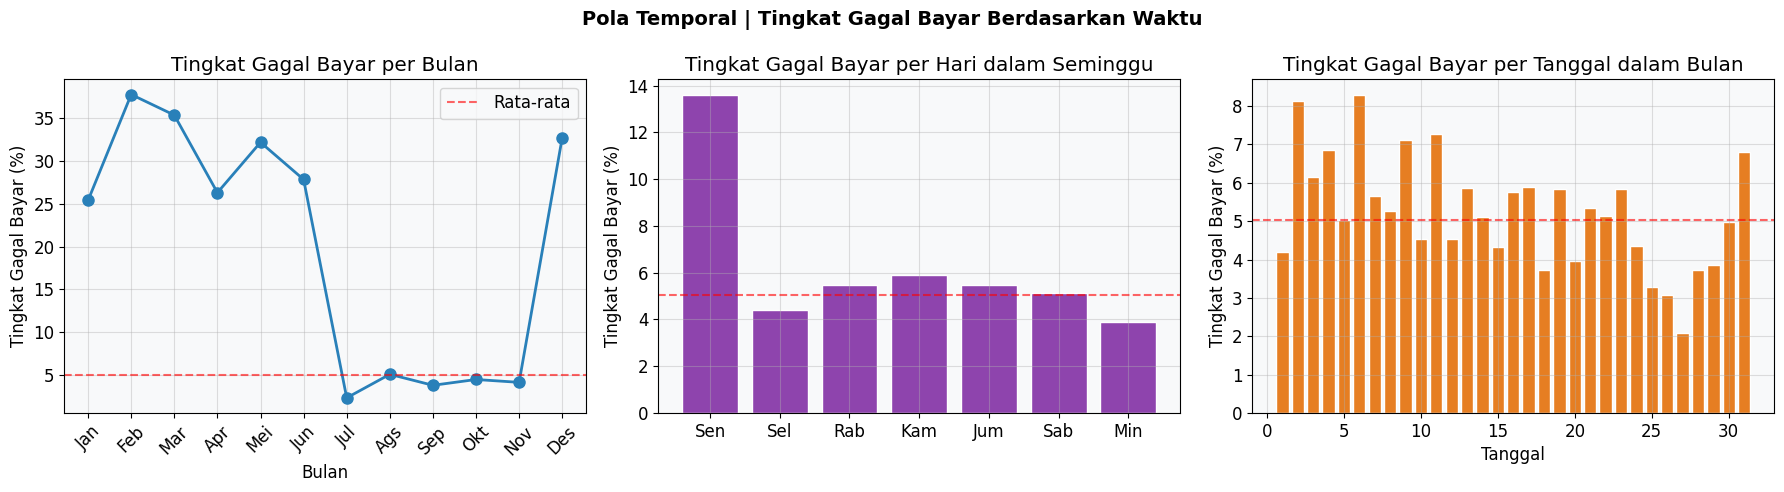

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Pola Temporal | Tingkat Gagal Bayar Berdasarkan Waktu", fontsize=14, fontweight="bold")

monthly = df_eda.groupby("bulan")["status_gagal_bayar"].mean()
axes[0].plot(monthly.index, monthly.values * 100, "o-", color="#2980b9", lw=2, ms=8)
axes[0].set_title("Tingkat Gagal Bayar per Bulan")
axes[0].set_xlabel("Bulan")
axes[0].set_ylabel("Tingkat Gagal Bayar (%)")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels([month_names[i] for i in range(1, 13)], rotation=45)
axes[0].axhline(y.mean()*100, color="red", linestyle="--", alpha=0.6, label="Rata-rata")
axes[0].legend()

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_dr = df_eda.groupby("hari_minggu")["status_gagal_bayar"].mean().reindex(day_order)
axes[1].bar(range(len(day_order)), day_dr.values * 100, color="#8e44ad", edgecolor="white")
axes[1].set_title("Tingkat Gagal Bayar per Hari dalam Seminggu")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Sen","Sel","Rab","Kam","Jum","Sab","Min"])
axes[1].set_ylabel("Tingkat Gagal Bayar (%)")
axes[1].axhline(y.mean()*100, color="red", linestyle="--", alpha=0.6)

tgl_dr = df_eda.groupby("tgl")["status_gagal_bayar"].mean()
axes[2].bar(tgl_dr.index, tgl_dr.values * 100, color="#e67e22", edgecolor="white")
axes[2].set_title("Tingkat Gagal Bayar per Tanggal dalam Bulan")
axes[2].set_xlabel("Tanggal")
axes[2].set_ylabel("Tingkat Gagal Bayar (%)")
axes[2].axhline(y.mean()*100, color="red", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


**INSIGHT TEMPORAL:**\
Pola temporal ada, meskipun tidak ekstrem.
Fitur bulan, hari, dan posisi tanggal membantu model menangkap seasonal pattern.

# **Feature Engineering**

Berdasarkan EDA di atas:

## Fitur Missing Indicator
**Alasan:** Missing `jenis_pinjaman` berhubungan dengan tingkat gagal bayar yang lebih tinggi (30% vs 4%). Missingness adalah **sinyal informasi**, bukan sekadar noise. Kita buat kolom binary `is_missing_*` untuk mengeksplisitkan sinyal ini.

## Fitur Finansial Derived
| Fitur Baru | Formula | Alasan |
|------------|---------|--------|
| `bunga_margin` | `(total_pengembalian - jumlah_pinjaman) / jumlah_pinjaman` | Korelasi 0.67 dengan target |
| `beban_cicilan` | `jumlah_pinjaman / durasi_hari` | Cicilan harian membuat tekanan arus kas peminjam |
| `rasio_lender` | `porsi_lender / total_pengembalian` | Proporsi yang ditanggung lender |
| `perbandingan_skor` | `jumlah_pinjaman / rata2_sektor` | Apakah pinjaman di atas/bawah rata-rata sektornya |

### Fitur Interaksi
**Alasan:** Model tree-based bisa menangkap interaksi, tapi fitur interaksi eksplisit mempercepat pembelajaran dan meningkatkan performa untuk relasi non-linear.

### Frequency Encoding
**Alasan:** Menggantikan kategori dengan frekuensi kemunculannya guna memberikan model informasi tentang "seberapa umum" kategori ini.

In [16]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Mengelompokkan kategori dengan frekuensi rendah menjadi '__RARE__'.

    Alasan: Kategori sangat langka cenderung overfit pada training set.
    Solusi: Kelompokkan kategori dengan frekuensi < min_freq menjadi '__RARE__'
    untuk mencegah target encoder mengoverfit pada kategori langka.
    """
    def __init__(self, min_freq=20, rare_label="__RARE__"):
        self.min_freq   = min_freq
        self.rare_label = rare_label
        self.keep_maps_ = {}
        self.columns_   = None

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self.columns_ = X.columns.tolist()
        self.keep_maps_ = {}
        for c in self.columns_:
            vc = X[c].astype(str).value_counts(dropna=False)
            self.keep_maps_[c] = set(vc[vc >= self.min_freq].index.astype(str).tolist())
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns_)
        df = X.copy()
        for c in self.columns_:
            keep = self.keep_maps_.get(c, set())
            s    = df[c].astype(str)
            df[c] = np.where(s.isin(keep), s, self.rare_label)
        return df


class CustomFE(BaseEstimator, TransformerMixin):
    """Feature Engineering berdasarkan insight EDA.

    Meliputi:
    - Missing indicators (missingness informatif pada jenis_pinjaman)
    - Fitur finansial derived (bunga_margin, beban_cicilan, rasio_lender)
    - Fitur perbandingan terhadap rata-rata sektor
    - Fitur temporal (bulan, hari, posisi tanggal)
    - Fitur interaksi antar variabel kunci
    - Frequency encoding untuk fitur kategorikal
    """
    def __init__(self):
        self.mean_loan_map_   = None
        self.global_mean_loan_ = None
        self.cat_count_maps_  = {}

    def fit(self, X, y=None):
        df = X.copy()
        self.mean_loan_map_    = df.groupby("jenis_pinjaman")["jumlah_pinjaman"].mean()
        self.global_mean_loan_ = df["jumlah_pinjaman"].mean()
        cat_cols = df.select_dtypes(include="object").columns.tolist()
        for c in cat_cols:
            self.cat_count_maps_[c] = df[c].astype(str).value_counts(dropna=False).to_dict()
        return self

    def transform(self, X):
        df = X.copy()

        # 1. Missing indicators (missingness informatif!)
        df["jenis_pinjaman"] = df["jenis_pinjaman"].fillna("Unknown")
        df["is_missing_total_pengembalian"]        = df["total_pengembalian"].isnull().astype(int)
        df["is_missing_durasi_hari"]               = df["durasi_hari"].isnull().astype(int)
        df["is_missing_porsi_pengembalian_lender"] = df["porsi_pengembalian_lender"].isnull().astype(int)

        # 2. Fitur finansial derived (berdasarkan korelasi tinggi dengan target)
        durasi_tmp = df["durasi_hari"].fillna(1)
        df["beban_cicilan"] = df["jumlah_pinjaman"] / durasi_tmp

        total_tmp = df["total_pengembalian"].fillna(df["jumlah_pinjaman"])
        df["bunga_margin"] = (total_tmp - df["jumlah_pinjaman"]) / df["jumlah_pinjaman"]

        porsi_tmp = df["porsi_pengembalian_lender"].fillna(0)
        df["rasio_lender"] = porsi_tmp / total_tmp

        # 3. Perbandingan terhadap rata-rata sektor
        mean_sector = df["jenis_pinjaman"].map(self.mean_loan_map_)
        mean_sector = mean_sector.fillna(self.global_mean_loan_)
        df["perbandingan_skor"] = df["jumlah_pinjaman"] / (mean_sector + 1e-9)

        # 4. Fitur temporal
        df["tanggal_pencairan"]      = pd.to_datetime(df["tanggal_pencairan"], errors="coerce")
        df["is_missing_tanggal"]     = df["tanggal_pencairan"].isna().astype(int)
        df["bulan"]                  = df["tanggal_pencairan"].dt.month
        df["hari_dalam_minggu_num"]  = df["tanggal_pencairan"].dt.weekday
        df["tgl_dalam_bulan_num"]    = df["tanggal_pencairan"].dt.day
        df["is_month_start"]         = df["tanggal_pencairan"].dt.is_month_start.astype("float").fillna(0).astype(int)
        df["is_month_end"]           = df["tanggal_pencairan"].dt.is_month_end.astype("float").fillna(0).astype(int)

        day = df["tanggal_pencairan"].dt.day
        dim = df["tanggal_pencairan"].dt.days_in_month
        df["hari_dalam_bulan"] = np.select(
            [day <= 10, day > (dim - 10)], ["awal", "akhir"], default="tengah"
        )

        # 5. Fitur interaksi (menangkap relasi non-linear antar variabel kunci)
        df["interaksi_bunga_durasi"] = df["bunga_margin"] * df["durasi_hari"]
        df["interaksi_bunga_total"]  = df["bunga_margin"] * df["total_pengembalian"]
        df["interaksi_lender_bunga"] = df["rasio_lender"] * df["bunga_margin"]
        df["interaksi_total_durasi"] = df["total_pengembalian"] / (df["durasi_hari"].fillna(0) + 1)
        df["interaksi_skor_bunga"]   = df["perbandingan_skor"] * df["bunga_margin"]

        # 6. Frequency encoding
        cat_cols = df.select_dtypes(include="object").columns.tolist()
        for c in cat_cols:
            mp = self.cat_count_maps_.get(c, {})
            df[f"freq_{c}"] = df[c].astype(str).map(mp).fillna(0).astype(float)

        return df.replace([np.inf, -np.inf], np.nan)

print("Custom transformers berhasil!")

Custom transformers berhasil!


---
# **Preprocessing Pipeline**

### Strategi Preprocessing

**Urutan untuk Fitur Kategorikal:**
1. **Rare Category Bucketing** untuk mengelompokkan kategori langka (mengurangi noise dan overfitting)
2. **Imputation** untuk mengisi nilai missing dengan modus
3. **Target Encoding** untuk mengkonversi kategori ke nilai numerik berdasarkan rata-rata target

**Kenapa Target Encoding vs One-Hot Encoding?**
- Fitur seperti `jenis_pinjaman` memiliki hubungan yang sangat kuat dan ordinal dengan target
- Target encoding menangkap hubungan ini lebih efektif dari OHE
- `min_samples_leaf` dan `smoothing` bertindak sebagai regularisasi

**Untuk Fitur Numerik:**
- Median imputation agar lebih robust terhadap outlier dibanding mean
- LightGBM tidak memerlukan scaling

In [17]:
def build_preprocessor(X_fe, min_freq_rare=20, te_msl=30, te_sm=10):
    """
    Membangun ColumnTransformer pipeline untuk preprocessing.

    Parameters:
    X_fe          : DataFrame setelah feature engineering
    min_freq_rare : threshold frekuensi minimum untuk rare bucketing
    te_msl        : min_samples_leaf untuk Target Encoder (regularisasi)
    te_sm         : smoothing untuk Target Encoder (regularisasi)
    """
    num_cols = X_fe.select_dtypes(include=np.number).columns.tolist()
    if "id_transaksi" in num_cols:
        num_cols.remove("id_transaksi")  # ID bukan fitur prediktif

    cat_cols = X_fe.select_dtypes(include="object").columns.tolist()

    numeric_tf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_tf = Pipeline([
        ("rare",    RareCategoryGrouper(min_freq=min_freq_rare)),
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target",  ce.TargetEncoder(min_samples_leaf=te_msl, smoothing=te_sm)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols),
        ],
        verbose_feature_names_out=False
    )

print("build_preprocessor() siap digunakan!")

build_preprocessor() siap digunakan!


# Modelling

| Kriteria | Dataset Kita | Kecocokan LightGBM |
|----------|-------------|---------------------|
| Ukuran data | 20K baris, ~30 fitur | Efisien untuk skala menengah |
| Tipe fitur | Campuran numerik & kategorikal | Menangani keduanya secara native |
| Class imbalance | 95:5 | Parameter `scale_pos_weight` |
| Non-linearity | Fitur interaksi kompleks | Tree-based menangkap non-linear |
| Speed | - | Salah satu yang tercepat |

## Strategi Penanganan Imbalance

`scale_pos_weight = n_negative / n_positive ≈ 19x`

Memberikan bobot lebih tinggi pada kelas minoritas agar model tidak mengabaikannya.

## Early Stopping
Menggunakan `n_estimators=10000` dengan early stopping (150 rounds) untuk menghentikan training ketika validation loss tidak membaik. Ini mencegah overfitting sekaligus menemukan jumlah optimal pohon.

# Hyperparameter Tuning dengan Optuna

### Mengapa Optuna?
- **TPE (Tree-structured Parzen Estimator):** Lebih efisien dari Grid Search atau Random Search
- **MedianPruner:** Menghentikan trial yang tidak menjanjikan lebih awal
- **Stratified K-Fold (3 folds):** Estimasi performa yang robust

### Custom Threshold Optimization
Threshold default 0.5 tidak optimal untuk data imbalanced. Kita optimasi threshold yang memaksimalkan F1-Macro pada setiap fold.

In [18]:
# Fixed folds untuk reproducibility
skf   = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
folds = list(skf.split(X, y))

print(f"Stratified K-Fold: {len(folds)} fold")
for i, (tr_idx, va_idx) in enumerate(folds):
    pos_tr = y.iloc[tr_idx].sum()
    pos_va = y.iloc[va_idx].sum()
    print(f"  Fold {i+1}: Train={len(tr_idx)} (pos={pos_tr}, {pos_tr/len(tr_idx):.2%}), "
          f"Val={len(va_idx)} (pos={pos_va}, {pos_va/len(va_idx):.2%})")


def objective(trial):
    prep_cfg = dict(
        min_freq_rare=trial.suggest_categorical("min_freq_rare", [10, 20, 50]),
        te_msl=trial.suggest_categorical("te_min_samples_leaf", [20, 30, 50]),
        te_sm=trial.suggest_categorical("te_smoothing", [8, 10, 15]),
    )
    spw_mult = trial.suggest_float("spw_mult", 0.8, 1.2)

    params_model = dict(
        n_estimators=10000,
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.06, log=True),
        num_leaves=trial.suggest_int("num_leaves", 24, 64),
        max_depth=trial.suggest_int("max_depth", 5, 10),
        min_child_samples=trial.suggest_int("min_child_samples", 40, 120),
        subsample=trial.suggest_float("subsample", 0.8, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.8, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 1.5),
        reg_lambda=trial.suggest_float("reg_lambda", 0.0, 1.5),
        min_split_gain=trial.suggest_float("min_split_gain", 0.0, 0.2),
        objective="binary",
        n_jobs=-1,
        verbosity=-1,
    )

    fold_scores = []
    for fold_id, (tr_idx, va_idx) in enumerate(folds):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pos = (y_tr == 1).sum()
        neg = (y_tr == 0).sum()
        spw = (neg / max(pos, 1)) * spw_mult

        fe = CustomFE()
        X_tr_fe = fe.fit_transform(X_tr, y_tr)
        X_va_fe = fe.transform(X_va)

        preprocess  = build_preprocessor(X_tr_fe, **prep_cfg)
        X_tr_mat    = preprocess.fit_transform(X_tr_fe, y_tr)
        X_va_mat    = preprocess.transform(X_va_fe)

        model = LGBMClassifier(**params_model, scale_pos_weight=spw, random_state=1000 + fold_id)
        model.fit(
            X_tr_mat, y_tr.to_numpy(),
            eval_set=[(X_va_mat, y_va.to_numpy())],
            eval_metric="binary_logloss",
            callbacks=[early_stopping(stopping_rounds=150, verbose=False)]
        )

        proba = model.predict_proba(X_va_mat)[:, 1]

        best_f1, best_th = -1, 0.5
        for th in np.arange(0.05, 0.95, 0.02):
            pred = (proba >= th).astype(int)
            f1m  = f1_score(y_va, pred, average="macro")
            if f1m > best_f1:
                best_f1, best_th = f1m, th

        lo, hi = max(0.01, best_th-0.05), min(0.99, best_th+0.05)
        for th in np.arange(lo, hi + 1e-9, 0.01):
            pred = (proba >= th).astype(int)
            f1m  = f1_score(y_va, pred, average="macro")
            if f1m > best_f1:
                best_f1, best_th = f1m, th

        fold_scores.append(best_f1)
        trial.report(float(np.mean(fold_scores)), step=fold_id)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

print()
print("Memulai Optuna hyperparameter search...")
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=8, n_warmup_steps=1)
)
study.optimize(objective, n_trials=25, show_progress_bar=True)

print()
print("=" * 60)
print("HASIL HYPERPARAMETER TUNING")
print("=" * 60)
print(f"  Best OOF F1-Macro : {study.best_value:.6f}")
print(f"  Best Params:")
for k, v in study.best_params.items():
    print(f"    {k:<30} : {v}")

best = study.best_params.copy()

Stratified K-Fold: 3 fold
  Fold 1: Train=13341 (pos=671, 5.03%), Val=6671 (pos=335, 5.02%)
  Fold 2: Train=13341 (pos=670, 5.02%), Val=6671 (pos=336, 5.04%)
  Fold 3: Train=13342 (pos=671, 5.03%), Val=6670 (pos=335, 5.02%)

Memulai Optuna hyperparameter search...


  0%|          | 0/25 [00:00<?, ?it/s]


HASIL HYPERPARAMETER TUNING
  Best OOF F1-Macro : 0.931174
  Best Params:
    min_freq_rare                  : 20
    te_min_samples_leaf            : 30
    te_smoothing                   : 15
    spw_mult                       : 1.1008003790084617
    learning_rate                  : 0.026077530779769285
    num_leaves                     : 34
    max_depth                      : 10
    min_child_samples              : 61
    subsample                      : 0.8600542777240492
    colsample_bytree               : 0.8002668139099105
    reg_alpha                      : 0.3805826149392157
    reg_lambda                     : 0.7025982975815915
    min_split_gain                 : 0.016501616521104386


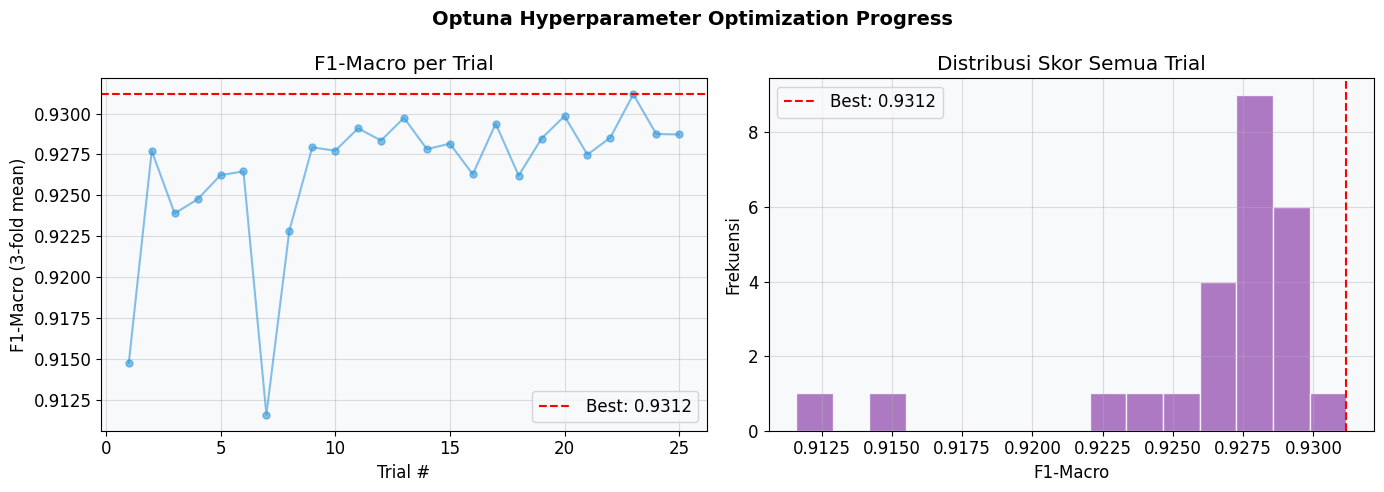

Total trials    : 25
Skor tertinggi  : 0.931174
Skor terendah   : 0.911595
Skor rata-rata  : 0.926480


In [19]:
trial_values = [t.value for t in study.trials if t.value is not None]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optuna Hyperparameter Optimization Progress", fontsize=14, fontweight="bold")

axes[0].plot(range(1, len(trial_values)+1), trial_values, "o-", alpha=0.6, color="#3498db", ms=5)
axes[0].axhline(y=max(trial_values), color="red", linestyle="--", label=f"Best: {max(trial_values):.4f}")
axes[0].set_title("F1-Macro per Trial")
axes[0].set_xlabel("Trial #")
axes[0].set_ylabel("F1-Macro (3-fold mean)")
axes[0].legend()

axes[1].hist(trial_values, bins=15, color="#9b59b6", edgecolor="white", alpha=0.8)
axes[1].axvline(x=max(trial_values), color="red", linestyle="--", label=f"Best: {max(trial_values):.4f}")
axes[1].set_title("Distribusi Skor Semua Trial")
axes[1].set_xlabel("F1-Macro")
axes[1].set_ylabel("Frekuensi")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total trials    : {len(trial_values)}")
print(f"Skor tertinggi  : {max(trial_values):.6f}")
print(f"Skor terendah   : {min(trial_values):.6f}")
print(f"Skor rata-rata  : {np.mean(trial_values):.6f}")

# OOF (Out-of-Fold) Prediction

## OOF Evaluation
OOF (Out-of-Fold) prediction evaluation lebih **robust** dibanding single holdout:
- Setiap data point di training set pernah menjadi data validasi tepat 1x
- Memberikan estimasi performa yang lebih reliable dan tidak bias
- Memaksimalkan penggunaan data training

## Threshold Optimization
Threshold default (0.5) tidak optimal untuk data imbalanced. Cari threshold yang memaksimalkan F1-Macro pada OOF predictions.

In [20]:
prep_cfg = dict(
    min_freq_rare=best["min_freq_rare"],
    te_msl=best["te_min_samples_leaf"],
    te_sm=best["te_smoothing"],
)
spw_mult = best["spw_mult"]

model_params = dict(
    n_estimators=10000,
    learning_rate=best["learning_rate"],
    num_leaves=best["num_leaves"],
    max_depth=best["max_depth"],
    min_child_samples=best["min_child_samples"],
    subsample=best["subsample"],
    colsample_bytree=best["colsample_bytree"],
    reg_alpha=best["reg_alpha"],
    reg_lambda=best["reg_lambda"],
    min_split_gain=best["min_split_gain"],
    objective="binary",
    n_jobs=-1,
    verbosity=-1,
)

oof_proba = np.zeros(len(X), dtype=float)

for fold_id, (tr_idx, va_idx) in enumerate(folds):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    pos = (y_tr == 1).sum()
    neg = (y_tr == 0).sum()
    spw = (neg / max(pos, 1)) * spw_mult

    fe = CustomFE()
    X_tr_fe = fe.fit_transform(X_tr, y_tr)
    X_va_fe = fe.transform(X_va)

    preprocess = build_preprocessor(X_tr_fe, **prep_cfg)
    X_tr_mat   = preprocess.fit_transform(X_tr_fe, y_tr)
    X_va_mat   = preprocess.transform(X_va_fe)

    model = LGBMClassifier(**model_params, scale_pos_weight=spw, random_state=SEED + fold_id)
    model.fit(
        X_tr_mat, y_tr.to_numpy(),
        eval_set=[(X_va_mat, y_va.to_numpy())],
        eval_metric="binary_logloss",
        callbacks=[early_stopping(stopping_rounds=150, verbose=False)]
    )
    oof_proba[va_idx] = model.predict_proba(X_va_mat)[:, 1]
    print(f"  Fold {fold_id+1}/3 selesai")

best_th, best_f1 = 0.5, -1
for th in np.arange(0.05, 0.95, 0.01):
    pred = (oof_proba >= th).astype(int)
    f1m  = f1_score(y, pred, average="macro")
    if f1m > best_f1:
        best_f1, best_th = f1m, th

print(f"\nOOF F1-Macro optimal : {best_f1:.6f}")
print(f"Threshold optimal    : {best_th:.2f}")

  Fold 1/3 selesai
  Fold 2/3 selesai
  Fold 3/3 selesai

OOF F1-Macro optimal : 0.928101
Threshold optimal    : 0.72


OOF CLASSIFICATION REPORT
                 precision    recall  f1-score   support

     Lancar (0)     0.9926    0.9929    0.9928     19006
Gagal Bayar (1)     0.8660    0.8608    0.8634      1006

       accuracy                         0.9863     20012
      macro avg     0.9293    0.9269    0.9281     20012
   weighted avg     0.9863    0.9863    0.9863     20012



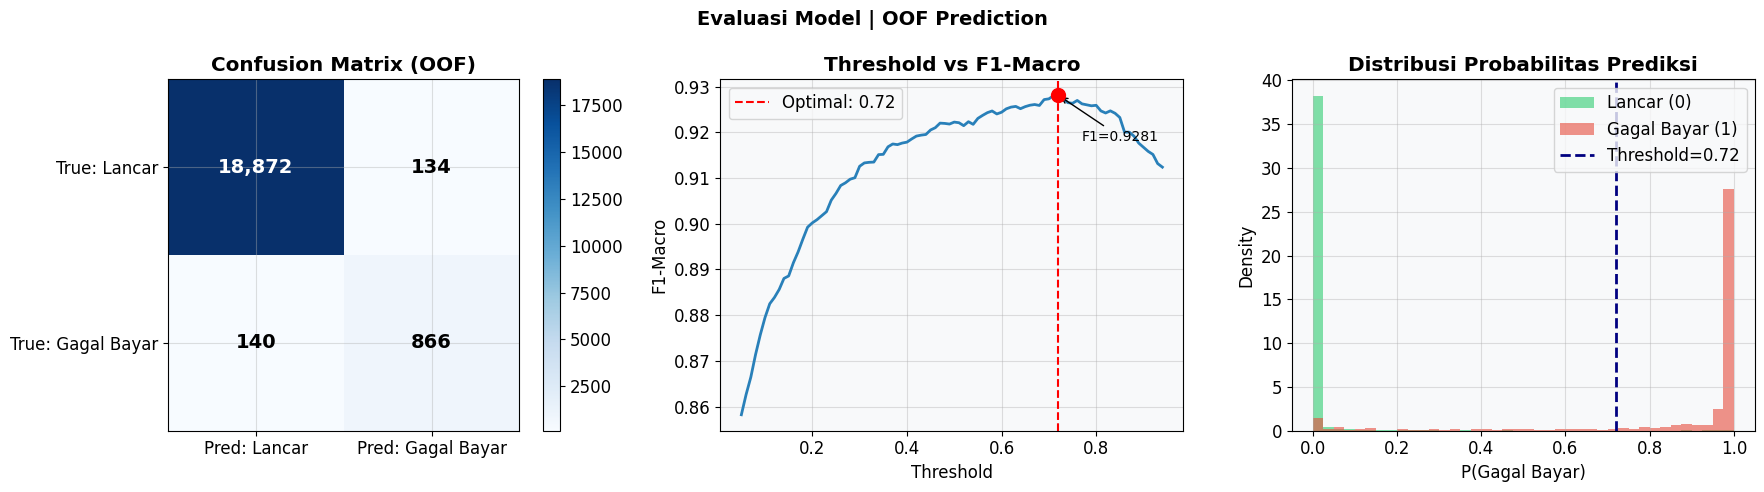

INTERPRETASI HASIL:
  Precision Gagal Bayar : Saat memprediksi 'gagal bayar', seberapa sering benar
  Recall Gagal Bayar    : Dari semua gagal bayar aktual, seberapa banyak berhasil ditangkap
  F1-Macro              : Rata-rata F1 kedua kelas untuk metrik utama kompetisi


In [21]:
oof_pred = (oof_proba >= best_th).astype(int)

print("=" * 60)
print("OOF CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y, oof_pred, digits=4,
      target_names=["Lancar (0)", "Gagal Bayar (1)"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Evaluasi Model | OOF Prediction", fontsize=14, fontweight="bold")

# 1. Confusion Matrix
cm = confusion_matrix(y, oof_pred)
im = axes[0].imshow(cm, interpolation="nearest", cmap="Blues")
axes[0].set_title("Confusion Matrix (OOF)", fontweight="bold")
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["Pred: Lancar", "Pred: Gagal Bayar"])
axes[0].set_yticklabels(["True: Lancar", "True: Gagal Bayar"])
thr = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                     fontsize=14, fontweight="bold",
                     color="white" if cm[i,j] > thr else "black")

# 2. Threshold vs F1-Macro Curve
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y, (oof_proba >= th).astype(int), average="macro")
              for th in thresholds]
axes[1].plot(thresholds, f1_scores, color="#2980b9", lw=2)
axes[1].axvline(x=best_th, color="red", linestyle="--", label=f"Optimal: {best_th:.2f}")
axes[1].scatter([best_th], [best_f1], color="red", s=100, zorder=5)
axes[1].set_title("Threshold vs F1-Macro", fontweight="bold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1-Macro")
axes[1].legend()
axes[1].annotate(f"F1={best_f1:.4f}", xy=(best_th, best_f1),
                 xytext=(best_th+0.05, best_f1-0.01), fontsize=10,
                 arrowprops=dict(arrowstyle="->"))

# 3. Probability Distribution
axes[2].hist(oof_proba[y==0], bins=40, alpha=0.6, color=PALETTE[0], label="Lancar (0)", density=True)
axes[2].hist(oof_proba[y==1], bins=40, alpha=0.6, color=PALETTE[1], label="Gagal Bayar (1)", density=True)
axes[2].axvline(x=best_th, color="navy", linestyle="--", lw=2, label=f"Threshold={best_th:.2f}")
axes[2].set_title("Distribusi Probabilitas Prediksi", fontweight="bold")
axes[2].set_xlabel("P(Gagal Bayar)")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.tight_layout()
plt.show()

print("INTERPRETASI HASIL:")
print("  Precision Gagal Bayar : Saat memprediksi 'gagal bayar', seberapa sering benar")
print("  Recall Gagal Bayar    : Dari semua gagal bayar aktual, seberapa banyak berhasil ditangkap")
print("  F1-Macro              : Rata-rata F1 kedua kelas untuk metrik utama kompetisi")

## Validasi Holdout (20%)

Sebagai cross-check tambahan, evaluasi model pada holdout set 20% menggunakan threshold yang sama dari OOF untuk memverifikasi tidak ada overfitting.

In [22]:
X_tr_h, X_va_h, y_tr_h, y_va_h = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

pos_h = (y_tr_h == 1).sum()
neg_h = (y_tr_h == 0).sum()
spw_h = (neg_h / max(pos_h, 1)) * spw_mult

fe_h       = CustomFE()
X_tr_h_fe  = fe_h.fit_transform(X_tr_h, y_tr_h)
X_va_h_fe  = fe_h.transform(X_va_h)

pre_h      = build_preprocessor(X_tr_h_fe, **prep_cfg)
X_tr_h_mat = pre_h.fit_transform(X_tr_h_fe, y_tr_h)
X_va_h_mat = pre_h.transform(X_va_h_fe)

m_h = LGBMClassifier(**model_params, scale_pos_weight=spw_h, random_state=777)
m_h.fit(
    X_tr_h_mat, y_tr_h.to_numpy(),
    eval_set=[(X_va_h_mat, y_va_h.to_numpy())],
    eval_metric="binary_logloss",
    callbacks=[early_stopping(stopping_rounds=150, verbose=False)]
)

proba_h = m_h.predict_proba(X_va_h_mat)[:, 1]
pred_h  = (proba_h >= best_th).astype(int)
f1_h    = f1_score(y_va_h, pred_h, average="macro")

print("HOLDOUT (20%) dengan MENGGUNAKAN THRESHOLD OOF")
print("=" * 60)
print(classification_report(y_va_h, pred_h, digits=4,
      target_names=["Lancar (0)", "Gagal Bayar (1)"]))
print(f"  F1-Macro Holdout : {f1_h:.6f}")
print(f"  F1-Macro OOF     : {best_f1:.6f}")
gap = abs(best_f1 - f1_h)
print(f"  Gap (Overfit?)   : {gap:.4f} ({'OK' if gap < 0.01 else 'Perlu dicek'})")

HOLDOUT (20%) dengan MENGGUNAKAN THRESHOLD OOF
                 precision    recall  f1-score   support

     Lancar (0)     0.9934    0.9937    0.9936      3802
Gagal Bayar (1)     0.8800    0.8756    0.8778       201

       accuracy                         0.9878      4003
      macro avg     0.9367    0.9347    0.9357      4003
   weighted avg     0.9877    0.9878    0.9877      4003

  F1-Macro Holdout : 0.935681
  F1-Macro OOF     : 0.928101
  Gap (Overfit?)   : 0.0076 (OK)
